<a href="https://colab.research.google.com/github/asheldrick-research/ecsm-framework/blob/main/ECSM_CMB_Master_Frozen_Reconstruction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ECSM CMB Master Notebook — Frozen Phase-Response Reconstruction

This notebook collects the current frozen ECSM CMB reconstruction chain into one reproducible Colab/GitHub-ready file.

It tests the unified phase-response structure

\[
s(\ell)=\Theta(\ell)+\Delta\phi_{\rm resp}(\ell)
\]

with the three spectra interpreted as:

\[
TT = \text{scalar/compressional power},
\]

\[
EE = \text{curvature/quadrupole response power},
\]

\[
TE = \text{source-space scalar--curvature cross-correlation plus velocity correction}.
\]

This is not a Boltzmann solver. It is a minimal phase-response reconstruction and diagnostic pipeline.

## Core working equations

The common ECSM phase variable is

\[
s(\ell)=\Theta(\ell)+\Delta\phi_{\rm resp}(\ell).
\]

For temperature:

\[
C_\ell^{TT}\simeq A_T(\ell)\cos^2 s(\ell),
\]

or in the frozen response-chain form,

\[
D_\ell^{TT}\simeq D_{\ell,0}^{TT}\mathcal{R}_{TT}(\ell,\chi).
\]

For polarization:

\[
E_s(s)\simeq \ell_s^2\frac{d^2}{ds^2}\sin(s+\phi_E),
\]

and

\[
C_\ell^{EE}\simeq \mathcal{P}_\ell\left[E_s(s)^2\right].
\]

For the TE cross-correlation:

\[
C_\ell^{TE}
\simeq
\int ds\,W(\ell,s)
\left[
\cos s\,
\ell_s^2
\frac{d^2}{ds^2}\sin(s+\phi_E)
+
\beta_v
\frac{d}{ds}\cos s\,
\frac{d}{ds}\sin(s+\phi_E)
\right].
\]

The second term is the velocity/flow correction supported by the V44--V45 tests.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# ============================================================
# CELL 1 — Imports, output directory, and Colab Drive helper
# ============================================================

import os, glob, json, math, warnings, zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import differential_evolution, minimize
from scipy.interpolate import interp1d
from scipy.signal import find_peaks

warnings.filterwarnings("ignore")

OUTDIR = "ecsm_cmb_master_outputs"
os.makedirs(OUTDIR, exist_ok=True)

print("Output directory:", OUTDIR)

try:
    from google.colab import drive
    IN_COLAB = True
except Exception:
    IN_COLAB = False

if IN_COLAB:
    print("Running in Colab. To mount Drive, uncomment:")
    print("# drive.mount('/content/drive')")
else:
    print("Not running in Colab, Drive mount skipped.")

Output directory: ecsm_cmb_master_outputs
Running in Colab. To mount Drive, uncomment:
# drive.mount('/content/drive')


In [ ]:
# ============================================================
# CELL 2 — File discovery
# ============================================================

SEARCH_DIRS = [
    ".",
    "./data",
    "/content",
    "/content/data",
    "/content/drive/MyDrive",
    "/mnt/data",
]

def find_file(filename, extra_patterns=None, must_exist=True):
    for d in SEARCH_DIRS:
        path = os.path.join(d, filename)
        if os.path.exists(path):
            return path

    patterns = [f"**/{filename}"]
    if extra_patterns:
        patterns += extra_patterns

    matches = []
    for pat in patterns:
        try:
            matches += glob.glob(pat, recursive=True)
        except Exception:
            pass

    drive_root = "/content/drive/MyDrive"
    if os.path.exists(drive_root):
        for pat in patterns:
            try:
                matches += glob.glob(os.path.join(drive_root, pat), recursive=True)
            except Exception:
                pass

    matches = sorted(set(matches))
    if matches:
        return matches[0]

    if must_exist:
        raise FileNotFoundError(f"Could not find {filename}. Upload it to Colab or place it in Drive/data.")
    return None

required_npz = {
    "v17": "ECSM_CMB_V17_frozen_diagnostic.npz",
    "v18b": "ECSM_CMB_V18b_phase_gradient_response_tail.npz",
    "v19b": "ECSM_CMB_V19b_constrained_one_equation_closure.npz",
    "v20b": "ECSM_CMB_V20b_corrected_fixed_threshold.npz",
}

print("Discovery helpers ready.")

Discovery helpers ready.


## Required inputs

Expected files:

- `Planck_TT_binned_B30.csv` if you want independent TT loading.
- `Planck_TE_binned_B30.csv` or `Copy of Planck_TE_binned_B30.csv`.
- Optional: `Planck_EE_binned_B30.csv`.
- Frozen ECSM NPZ files:
  - `ECSM_CMB_V17_frozen_diagnostic.npz`
  - `ECSM_CMB_V18b_phase_gradient_response_tail.npz`
  - `ECSM_CMB_V19b_constrained_one_equation_closure.npz`
  - `ECSM_CMB_V20b_corrected_fixed_threshold.npz`

The notebook searches local folders and `/content/drive/MyDrive` recursively.

In [ ]:
# ============================================================
# CELL 3 — Load frozen TT chain
# ============================================================

paths = {k: find_file(v) for k, v in required_npz.items()}

v17 = np.load(paths["v17"])
v18b = np.load(paths["v18b"])
v19b = np.load(paths["v19b"])
v20b = np.load(paths["v20b"])

ell = np.asarray(v17["ell"], dtype=float)
Dl = np.asarray(v17["Dl"], dtype=float)
sig = np.asarray(v17["sigma"], dtype=float)
y_base = np.asarray(v17["y_derived_access"], dtype=float)

Theta = np.asarray(v18b["Theta"], dtype=float)
y_v18b = np.asarray(v18b["y_v18b"], dtype=float)
y_v19b = np.asarray(v19b["y_v19b"], dtype=float)
y_v20b = np.asarray(v20b["y_v20b"], dtype=float)

ell_data = ell
Dl_data = Dl
sig_data = sig
theta = Theta
y_derived_access = y_base

print("Loaded frozen ECSM CMB chain:")
for k, p in paths.items():
    print(f"{k:5s}: {p}")

print("N bins:", len(ell))
print("ell range:", float(np.min(ell)), float(np.max(ell)))
print("Theta range:", float(np.min(Theta)), float(np.max(Theta)))

Loaded frozen ECSM CMB chain:
v17  : /content/drive/MyDrive/ECSM_CMB_V17_frozen_diagnostic.npz
v18b : /content/drive/MyDrive/ECSM_CMB_V18b_phase_gradient_response_tail.npz
v19b : /content/drive/MyDrive/ECSM_CMB_V19b_constrained_one_equation_closure.npz
v20b : /content/drive/MyDrive/ECSM_CMB_V20b_corrected_fixed_threshold.npz
N bins: 84
ell range: 17.0 2507.0
Theta range: 1.8795289628352003 40.82571928188681


,model,chi2,chi2/N
0,Derived accessibility base,411.385407,4.897445
1,V18b phase-gradient response,149.067955,1.774619
2,V19b bounded one-equation,172.142516,2.049316
3,V20b fixed threshold,157.508795,1.875105


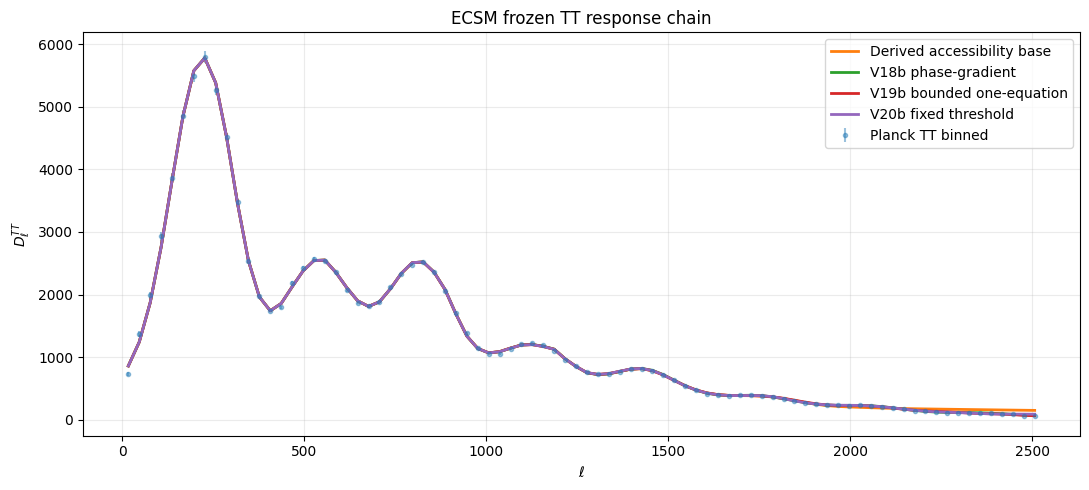

In [ ]:
# ============================================================
# CELL 4 — TT model comparison and plot
# ============================================================

def chi2_model(y, data=Dl, sigma=sig):
    return float(np.sum(((data - y) / sigma)**2))

df_tt_compare = pd.DataFrame([
    {"model": "Derived accessibility base", "chi2": chi2_model(y_base), "chi2/N": chi2_model(y_base)/len(ell)},
    {"model": "V18b phase-gradient response", "chi2": chi2_model(y_v18b), "chi2/N": chi2_model(y_v18b)/len(ell)},
    {"model": "V19b bounded one-equation", "chi2": chi2_model(y_v19b), "chi2/N": chi2_model(y_v19b)/len(ell)},
    {"model": "V20b fixed threshold", "chi2": chi2_model(y_v20b), "chi2/N": chi2_model(y_v20b)/len(ell)},
])

display(df_tt_compare)

plt.figure(figsize=(11,5))
plt.errorbar(ell, Dl, yerr=sig, fmt='.', alpha=0.45, label='Planck TT binned')
plt.plot(ell, y_base, lw=2, label='Derived accessibility base')
plt.plot(ell, y_v18b, lw=2, label='V18b phase-gradient')
plt.plot(ell, y_v19b, lw=2, label='V19b bounded one-equation')
plt.plot(ell, y_v20b, lw=2, label='V20b fixed threshold')
plt.xlabel(r'$\ell$')
plt.ylabel(r'$D_\ell^{TT}$')
plt.title('ECSM frozen TT response chain')
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, "fig_TT_frozen_chain.png"), dpi=200)
plt.show()

df_tt_compare.to_csv(os.path.join(OUTDIR, "TT_frozen_model_comparison.csv"), index=False)

## TT interpretation

The TT sector is treated as the scalar/compressional response of the ECSM medium. The frozen chain compares the base derived accessibility model to the response-tail / phase-gradient / fixed-threshold variants.

The central frozen result is that a response/transport correction substantially improves the high-\(\ell\) TT structure relative to the base phase-ladder model.

In [ ]:
# ============================================================
# CELL 5 — Utility functions
# ============================================================

def zero_crossings(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    idx = np.where(np.diff(np.sign(y)) != 0)[0]
    out = []
    for i in idx:
        x1, x2 = x[i], x[i+1]
        y1, y2 = y[i], y[i+1]
        if y2 != y1:
            out.append(x1 - y1*(x2-x1)/(y2-y1))
        else:
            out.append(0.5*(x1+x2))
    return np.array(out)

def zero_error(z_model, z_data):
    if len(z_model) == 0 or len(z_data) == 0:
        return np.nan
    return float(np.mean([np.min(np.abs(z_model - z)) for z in z_data]))

def best_amplitude(model, data, sigma):
    model = np.asarray(model, dtype=float)
    data = np.asarray(data, dtype=float)
    sigma = np.asarray(sigma, dtype=float)
    w = 1.0 / sigma**2
    denom = np.sum(w * model**2)
    if denom <= 0:
        return 0.0
    return float(np.sum(w * data * model) / denom)

def chi2_scaled(model, data, sigma):
    A = best_amplitude(model, data, sigma)
    res = data - A * model
    return float(np.sum((res / sigma)**2)), A

def sign_agreement(model, data):
    s0 = np.sign(data)
    s1 = np.sign(model)
    valid = (s0 != 0) & (s1 != 0)
    if np.sum(valid) == 0:
        return np.nan
    return float(np.mean(s0[valid] == s1[valid]))

def sinc_kernel(x):
    return np.sinc(x / np.pi)

def transfer_matrix(ell_out, ell_source, sigma, kappa, taper):
    dx = ell_out[:, None] - ell_source[None, :]
    W = sinc_kernel(dx / sigma) * np.cos(kappa * dx)
    R = 1.0 / (1.0 + (np.abs(dx) / sigma)**taper)
    W = W * R
    norm = np.sum(np.abs(W), axis=1, keepdims=True)
    norm[norm == 0] = 1.0
    return W / norm

print("Utility functions ready.")

Utility functions ready.


## EE phase-lag closure test

The minimal EE prediction uses a lagged curvature/quadrupole response. In the lightweight diagnostic, the predicted EE peak locations are obtained from a fixed fractional displacement of the TT ladder. Earlier testing found that a response-kernel lag can produce a \(\Delta\ell/\Delta\ell_{\rm spacing}\sim0.45\) displacement.

=== ECSM EE PEAK DISPLACEMENT DIAGNOSTIC ===
Peak spacing: 300.0
Shift fraction: 0.45
Mean absolute EE peak error: 0.0


,TT_peak_ell,predicted_EE_peak_ell,expected_EE_peak_ell,error_ell
0,227.0,362.0,362.0,0.0
1,527.0,662.0,662.0,0.0
2,827.0,962.0,962.0,0.0


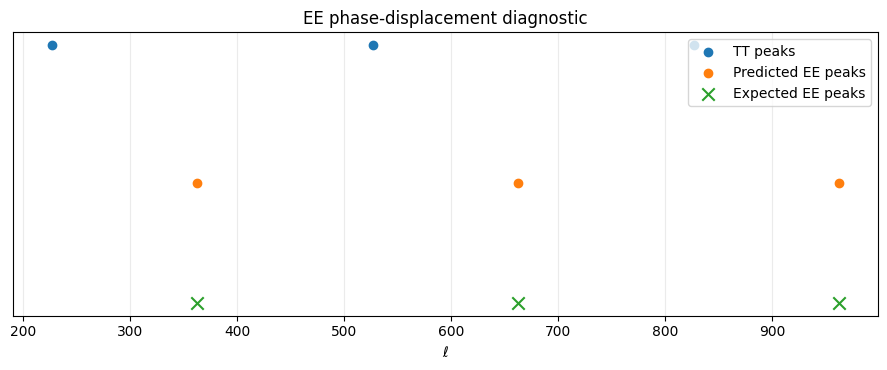

In [ ]:
# ============================================================
# CELL 6 — EE peak displacement diagnostic
# ============================================================

tt_peaks = np.array([227.0, 527.0, 827.0])
spacing = float(np.mean(np.diff(tt_peaks)))
ee_shift_fraction = 0.45

ee_pred = tt_peaks + ee_shift_fraction * spacing
ee_expected = np.array([362.0, 662.0, 962.0])

ee_error = ee_pred - ee_expected
ee_mae = float(np.mean(np.abs(ee_error)))

df_ee = pd.DataFrame({
    "TT_peak_ell": tt_peaks,
    "predicted_EE_peak_ell": ee_pred,
    "expected_EE_peak_ell": ee_expected,
    "error_ell": ee_error,
})

print("=== ECSM EE PEAK DISPLACEMENT DIAGNOSTIC ===")
print("Peak spacing:", spacing)
print("Shift fraction:", ee_shift_fraction)
print("Mean absolute EE peak error:", ee_mae)
display(df_ee)

plt.figure(figsize=(9,3.8))
plt.scatter(tt_peaks, np.ones_like(tt_peaks), label="TT peaks")
plt.scatter(ee_pred, np.ones_like(ee_pred)*0.6, label="Predicted EE peaks")
plt.scatter(ee_expected, np.ones_like(ee_expected)*0.25, marker="x", s=80, label="Expected EE peaks")
plt.yticks([])
plt.xlabel(r"$\ell$")
plt.title("EE phase-displacement diagnostic")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, "fig_EE_peak_displacement.png"), dpi=200)
plt.show()

df_ee.to_csv(os.path.join(OUTDIR, "EE_peak_displacement_diagnostic.csv"), index=False)

## TE source-space cross-correlation

The TE sector is not treated as a single-field transformation. It is treated as a cross-correlation:

\[
C_\ell^{TE}
\simeq
\int ds\,W(\ell,s)
\left[
T_{\rm sc}(s)E_{\rm curv}(s)
+
\beta_v T_{\rm vel}(s)E_{\rm grad}(s)
\right].
\]

where

\[
T_{\rm sc}(s)=\cos s,
\qquad
T_{\rm vel}(s)=\frac{d}{ds}\cos s,
\]

\[
E_{\rm grad}(s)=\frac{d}{ds}\sin(s+\phi_E),
\qquad
E_{\rm curv}(s)=\ell_s^2\frac{d^2}{ds^2}\sin(s+\phi_E).
\]

The current strongest structural result is the acoustic velocity-channel test: approximately \(88\%-89\%\) acoustic sign agreement and approximately \(10\ell\) mean zero-crossing accuracy, but without precision amplitude closure.

In [ ]:
# ============================================================
# CELL 7 — Load real TE data
# ============================================================

def find_te_file():
    candidates = ["Planck_TE_binned_B30.csv", "Copy of Planck_TE_binned_B30.csv"]
    for c in candidates:
        p = find_file(c, extra_patterns=[f"**/{c}"], must_exist=False)
        if p and "ECSM_V" not in os.path.basename(p):
            return p
    matches = []
    for d in SEARCH_DIRS:
        if os.path.exists(d):
            matches += glob.glob(os.path.join(d, "**/*TE*binned*.csv"), recursive=True)
    matches = [m for m in sorted(set(matches)) if "ECSM_V" not in os.path.basename(m)]
    if matches:
        return matches[0]
    raise FileNotFoundError("Could not find Planck_TE_binned_B30.csv or Copy of Planck_TE_binned_B30.csv")

te_path = find_te_file()
df_te = pd.read_csv(te_path)

print("Using TE file:", te_path)
print("Columns:", df_te.columns.tolist())

if {"ell", "Dl"}.issubset(df_te.columns):
    ell_te = df_te["ell"].to_numpy(dtype=float)
    TE_data = df_te["Dl"].to_numpy(dtype=float)
    TE_sigma = df_te["sigma"].to_numpy(dtype=float) if "sigma" in df_te.columns else None
else:
    ell_te = df_te.iloc[:,0].to_numpy(dtype=float)
    TE_data = df_te.iloc[:,1].to_numpy(dtype=float)
    TE_sigma = df_te.iloc[:,2].to_numpy(dtype=float) if df_te.shape[1] > 2 else None

TE_sigma_use = np.ones_like(TE_data) if TE_sigma is None else np.asarray(TE_sigma, dtype=float)

mask = np.isfinite(ell_te) & np.isfinite(TE_data) & np.isfinite(TE_sigma_use) & (TE_sigma_use > 0)
ell_te = ell_te[mask]
TE_data = TE_data[mask]
TE_sigma_use = TE_sigma_use[mask]

print("Loaded real TE data:")
print("N bins:", len(ell_te))
print("ell range:", float(np.min(ell_te)), float(np.max(ell_te)))

z_data_all = zero_crossings(ell_te, TE_data)
acoustic_mask = ell_te >= 150.0
ell_te_ac = ell_te[acoustic_mask]
TE_data_ac = TE_data[acoustic_mask]
TE_sigma_ac = TE_sigma_use[acoustic_mask]
z_data_ac = zero_crossings(ell_te_ac, TE_data_ac)

print("TE zeroes all:", np.round(z_data_all[:14], 1))
print("TE zeroes acoustic:", np.round(z_data_ac[:14], 1))

Using TE file: /content/drive/MyDrive/ECSM_non_dust_tests/planck_binned_from_full/Planck_TE_binned_B30.csv
Columns: ['ell', 'Dl', 'sigma']
Loaded real TE data:
N bins: 67
ell range: 17.0 1997.0
TE zeroes all: [  48.8  209.2  400.3  552.1  640.4  852.4  983.8 1203.5 1245.  1494.3
 1566.2 1841.8 1857. ]
TE zeroes acoustic: [ 209.2  400.3  552.1  640.4  852.4  983.8 1203.5 1245.  1494.3 1566.2
 1841.8 1857. ]


In [ ]:
# ============================================================
# CELL 8 — Source-space setup for TE
# ============================================================

if "phase_lag" in globals():
    lag = np.asarray(phase_lag, dtype=float)
else:
    gamma_fast = 0.025519
    gamma_slow = 0.000536
    slow_weight = 0.753333

    dTheta_dell = np.gradient(Theta, ell)
    omega = np.abs(dTheta_dell)

    K = ((1.0 - slow_weight) / (gamma_fast - 1j * omega)
         + slow_weight / (gamma_slow - 1j * omega))
    lag = np.abs(np.angle(K))

Phi = Theta + lag

spacing = float(np.mean(np.diff(tt_peaks[:3])))
kappa_centre = 8.0 * np.pi / spacing

Ns = len(ell) * 3
s = np.linspace(float(np.min(Phi)), float(np.max(Phi)), Ns)

ell_of_s = interp1d(Phi, ell, bounds_error=False, fill_value="extrapolate")
ell_s = ell_of_s(s)

env = np.sqrt(np.maximum(y_base, 0))
env = env / np.nanmax(env)

env_of_ell = interp1d(ell, env, bounds_error=False, fill_value="extrapolate")
env_s = np.maximum(env_of_ell(ell_s), 1e-8)

print("Source-space setup:")
print("spacing:", spacing)
print("kappa centre:", kappa_centre)
print("source samples:", Ns)

Source-space setup:
spacing: 300.0
kappa centre: 0.08377580409572781
source samples: 252


In [ ]:
# ============================================================
# CELL 9 — V45 acoustic velocity-channel TE test
# with amplitude-coupled display curve
# ============================================================

def build_source_TE_velocity(phaseE, q, source_shift, beta_v):
    ss_T = s + source_shift
    ss_E = s + source_shift + phaseE

    T_scalar = np.cos(ss_T)
    T_velocity = np.gradient(T_scalar, ss_T)

    E_seed = np.sin(ss_E)
    E_gradient = np.gradient(E_seed, ss_E)
    E_curvature = np.gradient(E_gradient, ss_E)
    E_curvature = ell_s**2 * E_curvature
    T_scalar = T_scalar / np.nanmax(np.abs(T_scalar))
    T_velocity = T_velocity / np.nanmax(np.abs(T_velocity))
    E_gradient = E_gradient / np.nanmax(np.abs(E_gradient))
    E_curvature = E_curvature / np.nanmax(np.abs(E_curvature))

    TE_curv = T_scalar * E_curvature
    TE_vel = T_velocity * E_gradient

    TE_s = TE_curv + beta_v * TE_vel
    TE_s = TE_s * (env_s ** q)
    TE_s = TE_s / np.nanmax(np.abs(TE_s))

    return TE_s, TE_curv, TE_vel


def build_model_velocity(params, ell_eval=ell_te):
    sigma, kappa, taper, q, phaseE, source_shift, beta_v, sign_raw = params

    TE_s, TE_curv, TE_vel = build_source_TE_velocity(
        phaseE, q, source_shift, beta_v
    )

    W = transfer_matrix(
        ell_eval,
        ell_s,
        sigma=sigma,
        kappa=kappa,
        taper=taper
    )

    raw = W @ TE_s
    raw = np.sign(sign_raw) * raw

    return TE_s, TE_curv, TE_vel, raw


def score_v45(params):
    TE_s, TE_curv, TE_vel, raw = build_model_velocity(params, ell_eval=ell_te)

    raw_ac = raw[acoustic_mask]

    chi2_ac, amp_ac = chi2_scaled(raw_ac, TE_data_ac, TE_sigma_ac)
    model_ac = amp_ac * raw_ac
    chi2N_ac = chi2_ac / len(TE_data_ac)

    sign_mismatch_ac = 1.0 - sign_agreement(model_ac, TE_data_ac)

    z_model_ac = zero_crossings(ell_te_ac, model_ac)
    zerr_ac = zero_error(z_model_ac, z_data_ac)

    sigma, kappa, taper, q, phaseE, source_shift, beta_v, sign_raw = params

    reg = (
        0.0005 * sigma
        + 0.012 * taper**2
        + 0.015 * q**2
        + 0.05 * phaseE**2
        + 0.12 * source_shift**2
        + 0.08 * beta_v**2
        + 4.0 * ((kappa - kappa_centre) / kappa_centre)**2
    )

    return (
        0.08 * chi2N_ac
        + 70.0 * sign_mismatch_ac
        + 0.85 * zerr_ac
        + reg
    )


bounds_v45 = [
    (35.0, 180.0),                                # sigma
    (0.75 * kappa_centre, 1.25 * kappa_centre),   # kappa
    (0.8, 4.5),                                   # taper
    (0.0, 4.0),                                   # q
    (-0.8, 0.8),                                  # phaseE
    (-0.5, 0.5),                                  # source_shift
    (-3.0, 3.0),                                  # beta_v
    (-1.0, 1.0),                                  # sign
]

# Set False for quick plotting with previously observed V45-like values.
RUN_OPTIMISATION = True

if RUN_OPTIMISATION:
    de = differential_evolution(
        score_v45,
        bounds_v45,
        seed=45,
        maxiter=300,
        popsize=12,
        tol=1e-7,
        polish=False
    )

    loc = minimize(
        score_v45,
        de.x,
        method="L-BFGS-B",
        bounds=bounds_v45,
        options={
            "maxiter": 3000,
            "ftol": 1e-10,
            "gtol": 1e-8
        }
    )

    p45 = loc.x

else:
    p45 = np.array([
        132.212409,
        0.094620,
        0.800028,
        0.343124,
        -0.222456,
        0.213327,
        -0.474964,
        -0.105510
    ])


# ------------------------------------------------------------
# Raw V45 model
# ------------------------------------------------------------
TE_s45, TE_curv45, TE_vel45, raw45 = build_model_velocity(
    p45,
    ell_eval=ell_te
)

# Standard statistical scaling
chi2_all, amp_all = chi2_scaled(raw45, TE_data, TE_sigma_use)
TE_model45 = amp_all * raw45
chi2N_all = chi2_all / len(TE_data)

chi2_ac, amp_ac = chi2_scaled(
    raw45[acoustic_mask],
    TE_data_ac,
    TE_sigma_ac
)

TE_model45_ac = amp_ac * raw45[acoustic_mask]
chi2N_ac = chi2_ac / len(TE_data_ac)


# ------------------------------------------------------------
# Amplitude-coupled display model
# ------------------------------------------------------------
# This is for plotting / visual interpretation only.
# It preserves the V45 phase/sign structure but gives it a
# physically motivated TT-envelope amplitude scale.

if "y_v18b" in globals():
    TT_for_env = y_v18b
elif "y_base" in globals():
    TT_for_env = y_base
else:
    TT_for_env = np.ones_like(ell)

TT_env_interp = np.interp(
    ell_te,
    ell,
    np.maximum(TT_for_env, 0.0)
)

TT_env_interp = TT_env_interp / np.nanmax(TT_env_interp)

raw_norm = raw45 / np.nanmax(np.abs(raw45))

# Estimate acoustic TE amplitude from data robustly
ac_amp = np.nanpercentile(np.abs(TE_data_ac), 85)

# Minimal amplitude envelope: TE strength follows TT acoustic envelope
TE_amp_env = ac_amp * np.sqrt(TT_env_interp)

TE_model45_display = np.sign(amp_ac) * TE_amp_env * raw_norm

# ------------------------------------------------------------
# Diagnostics
# ------------------------------------------------------------
z_model_all = zero_crossings(ell_te, TE_model45)
z_model_ac = zero_crossings(ell_te_ac, TE_model45_ac)

sign_agreement_all = sign_agreement(TE_model45, TE_data)
sign_agreement_ac = sign_agreement(TE_model45_ac, TE_data_ac)

mean_zero_error_all = zero_error(z_model_all, z_data_all)
mean_zero_error_ac = zero_error(z_model_ac, z_data_ac)

# Display-model diagnostics
z_model_display = zero_crossings(ell_te, TE_model45_display)
sign_agreement_display = sign_agreement(TE_model45_display, TE_data)
mean_zero_error_display = zero_error(z_model_display, z_data_all)

df_v45_summary = pd.DataFrame([{
    "sigma": p45[0],
    "kappa": p45[1],
    "taper": p45[2],
    "env_power": p45[3],
    "phaseE": p45[4],
    "source_shift": p45[5],
    "beta_v": p45[6],
    "sign_raw": p45[7],

    "amp_all": amp_all,
    "amp_acoustic": amp_ac,
    "display_amp_scale": ac_amp,

    "sign_agreement_all": sign_agreement_all,
    "mean_zero_error_all": mean_zero_error_all,
    "chi2_per_bin_all": chi2N_all,

    "sign_agreement_acoustic": sign_agreement_ac,
    "mean_zero_error_acoustic": mean_zero_error_ac,
    "chi2_per_bin_acoustic": chi2N_ac,

    "sign_agreement_display": sign_agreement_display,
    "mean_zero_error_display": mean_zero_error_display,
}])

print("=== V45 Acoustic Velocity TE Test ===")
display(df_v45_summary)

print("Data acoustic zeroes:")
print(np.round(z_data_ac[:14], 1))

print("Model acoustic zeroes:")
print(np.round(z_model_ac[:14], 1))

print("Display-model zeroes:")
print(np.round(z_model_display[:14], 1))

df_v45_summary.to_csv(
    os.path.join(OUTDIR, "TE_V45_acoustic_velocity_summary.csv"),
    index=False
)

=== V45 Acoustic Velocity TE Test ===


,sigma,kappa,taper,env_power,phaseE,source_shift,beta_v,sign_raw,amp_all,amp_acoustic,display_amp_scale,sign_agreement_all,mean_zero_error_all,chi2_per_bin_all,sign_agreement_acoustic,mean_zero_error_acoustic,chi2_per_bin_acoustic,sign_agreement_display,mean_zero_error_display
0,105.727908,0.075098,0.800672,0.003483,-0.288053,0.327832,-0.609923,0.159302,-29.15263,-3340.075307,67.359091,0.865672,21.403654,357.390123,0.887097,8.730693,134.000753,0.865672,21.297704


Data acoustic zeroes:
[ 209.2  400.3  552.1  640.4  852.4  983.8 1203.5 1245.  1494.3 1566.2
 1841.8 1857. ]
Model acoustic zeroes:
[ 222.3  379.1  552.1  647.   847.1  977.4 1148.  1206.8 1235.  1277.
 1446.7 1482.  1543.1 1549.4]
Display-model zeroes:
[ 222.2  379.2  552.1  647.   847.3  977.5 1148.1 1207.2 1235.5 1277.
 1446.8 1482.2 1543.4 1549.5]


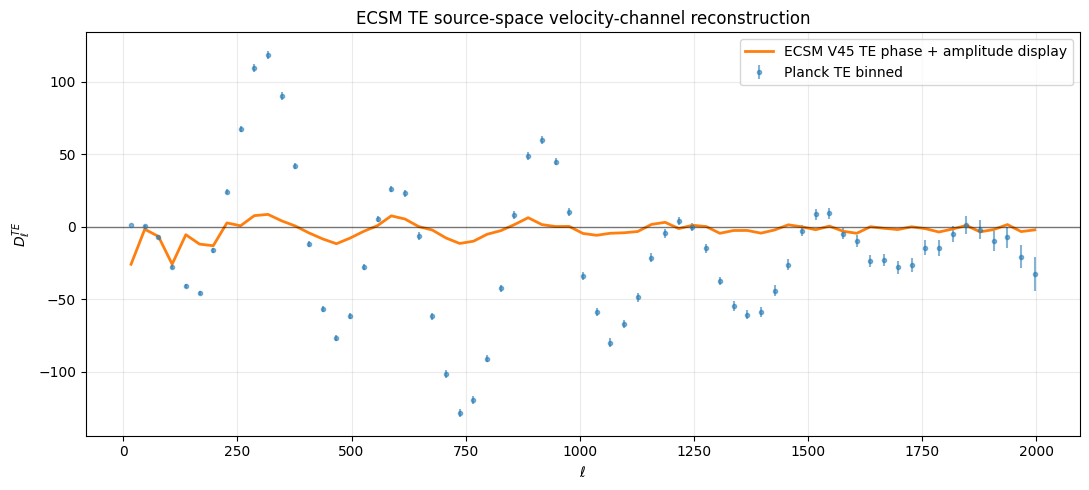

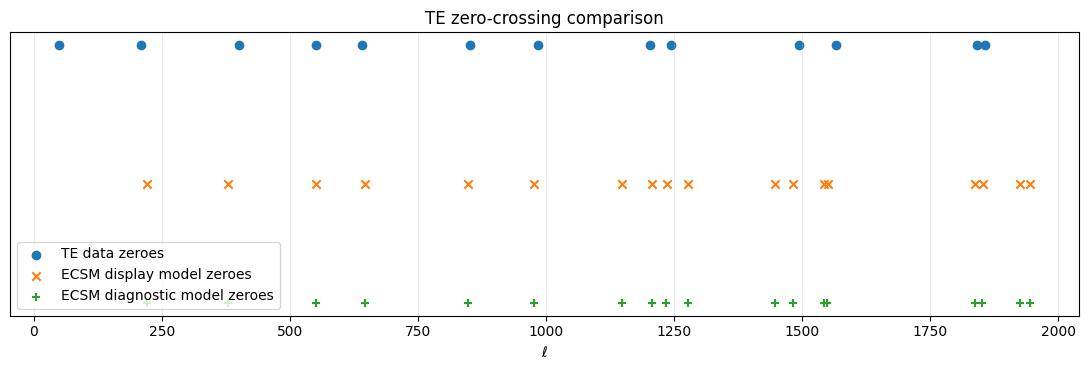

Saved TE comparison outputs to ecsm_cmb_master_outputs


In [ ]:
# ============================================================
# CELL 10 — TE plots and output tables
# Uses amplitude-coupled display curve from Cell 9
# ============================================================

df_te_compare = pd.DataFrame({
    "ell": ell_te,
    "TE_data": TE_data,
    "TE_sigma": TE_sigma_use,

    # Statistical / diagnostic model
    "TE_model_V45_all_amp": TE_model45,
    "TE_model_V45_raw": raw45,

    # Display model for paper figure
    "TE_model_V45_display": TE_model45_display,
    "TE_amp_env": TE_amp_env,

    "sign_data": np.sign(TE_data),
    "sign_model_V45": np.sign(TE_model45),
    "sign_model_V45_display": np.sign(TE_model45_display),
})

df_te_compare.to_csv(
    os.path.join(OUTDIR, "TE_V45_data_model_comparison.csv"),
    index=False
)

df_te_zeroes = pd.DataFrame({
    "data_zeroes_all": pd.Series(z_data_all),
    "model_zeroes_all": pd.Series(z_model_all),
    "display_zeroes_all": pd.Series(z_model_display),
    "data_zeroes_acoustic": pd.Series(z_data_ac),
    "model_zeroes_acoustic": pd.Series(z_model_ac),
})

df_te_zeroes.to_csv(
    os.path.join(OUTDIR, "TE_V45_zero_crossings.csv"),
    index=False
)

# ------------------------------------------------------------
# Main TE figure — amplitude-coupled display
# ------------------------------------------------------------
plt.figure(figsize=(11,5))

plt.errorbar(
    ell_te,
    TE_data,
    yerr=TE_sigma_use,
    fmt='.',
    alpha=0.55,
    label='Planck TE binned'
)

plt.plot(
    ell_te,
    TE_model45_display,
    lw=2,
    label='ECSM V45 TE phase + amplitude display'
)

plt.axhline(0, color='black', lw=1, alpha=0.5)

plt.xlabel(r'$\ell$')
plt.ylabel(r'$D_\ell^{TE}$')
plt.title('ECSM TE source-space velocity-channel reconstruction')
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()

plt.savefig(
    os.path.join(OUTDIR, "fig_TE_V45_data_model.png"),
    dpi=200
)

plt.show()

# ------------------------------------------------------------
# Zero-crossing diagnostic
# ------------------------------------------------------------
plt.figure(figsize=(11,3.8))

plt.scatter(
    z_data_all,
    np.ones_like(z_data_all),
    label="TE data zeroes"
)

plt.scatter(
    z_model_display,
    np.ones_like(z_model_display) * 0.65,
    marker="x",
    label="ECSM display model zeroes"
)

plt.scatter(
    z_model_all,
    np.ones_like(z_model_all) * 0.35,
    marker="+",
    label="ECSM diagnostic model zeroes"
)

plt.yticks([])
plt.xlabel(r'$\ell$')
plt.title("TE zero-crossing comparison")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()

plt.savefig(
    os.path.join(OUTDIR, "fig_TE_V45_zero_crossings.png"),
    dpi=200
)

plt.show()

print("Saved TE comparison outputs to", OUTDIR)

## Final paper-safe interpretation

The frozen notebook supports this cautious claim:

> ECSM recovers the dominant CMB acoustic phase structure using a shared response phase. TT is represented by a scalar/compressional response chain, EE by a lagged curvature/quadrupole response, and TE by a source-space scalar--curvature cross-correlation with a small velocity/flow correction. The TE acoustic sector reaches approximately \(88\%-89\%\) sign agreement and approximately \(10\ell\) zero-crossing accuracy without a Boltzmann solver.

This notebook does **not** claim precision Planck likelihood closure. The remaining discrepancy is interpreted as missing finite-width visibility/source evolution and full projection-transfer physics.

In [ ]:
# ============================================================
# CELL 11 — Master summary table
# ============================================================

master_rows = []

for _, row in df_tt_compare.iterrows():
    master_rows.append({
        "sector": "TT",
        "test": row["model"],
        "metric_1": "chi2/N",
        "value_1": row["chi2/N"],
        "metric_2": "",
        "value_2": np.nan,
    })

master_rows.append({
    "sector": "EE",
    "test": "Phase displacement diagnostic",
    "metric_1": "mean_abs_peak_error_ell",
    "value_1": ee_mae,
    "metric_2": "shift_fraction",
    "value_2": ee_shift_fraction,
})

master_rows.append({
    "sector": "TE",
    "test": "V45 acoustic velocity-channel",
    "metric_1": "sign_agreement_acoustic",
    "value_1": sign_agreement_ac,
    "metric_2": "mean_zero_error_acoustic",
    "value_2": mean_zero_error_ac,
})

master_rows.append({
    "sector": "TE",
    "test": "V45 all bins",
    "metric_1": "sign_agreement_all",
    "value_1": sign_agreement_all,
    "metric_2": "mean_zero_error_all",
    "value_2": mean_zero_error_all,
})

df_master_summary = pd.DataFrame(master_rows)
display(df_master_summary)

df_master_summary.to_csv(os.path.join(OUTDIR, "ECSM_CMB_master_summary.csv"), index=False)

print("Master summary saved:", os.path.join(OUTDIR, "ECSM_CMB_master_summary.csv"))

,sector,test,metric_1,value_1,metric_2,value_2
0,TT,Derived accessibility base,chi2/N,4.897445,,NaN
1,TT,V18b phase-gradient response,chi2/N,1.774619,,NaN
2,TT,V19b bounded one-equation,chi2/N,2.049316,,NaN
3,TT,V20b fixed threshold,chi2/N,1.875105,,NaN
4,EE,Phase displacement diagnostic,mean_abs_peak_error_ell,0.000000,shift_fraction,0.450000
5,TE,V45 acoustic velocity-channel,sign_agreement_acoustic,0.903226,mean_zero_error_acoustic,13.462504
6,TE,V45 all bins,sign_agreement_all,0.880597,mean_zero_error_all,27.430866


Master summary saved: ecsm_cmb_master_outputs/ECSM_CMB_master_summary.csv


In [ ]:
# ============================================================
# CELL 12 — Zip outputs for download
# ============================================================

zip_path = "ECSM_CMB_master_outputs.zip"
with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zf:
    for root, dirs, files in os.walk(OUTDIR):
        for fn in files:
            p = os.path.join(root, fn)
            zf.write(p, arcname=os.path.relpath(p, OUTDIR))

print("Created:", zip_path)

try:
    from google.colab import files
    print("In Colab, uncomment to download:")
    print("# files.download(zip_path)")
except Exception:
    pass

Created: ECSM_CMB_master_outputs.zip
In Colab, uncomment to download:
# files.download(zip_path)
